In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Change this to your actual path
DATASET_ROOT = r"E:\Pyhton code\Data Sets\archive\labeled wild face dataset 13000 images\lfw-deepfunneled"

# Actual image directory
DATASET_PATH = os.path.join(DATASET_ROOT, "lfw-deepfunneled")

print("Dataset root exists:", os.path.exists(DATASET_ROOT))
print("Image dataset exists:", os.path.exists(DATASET_PATH))

people = [
    folder for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, folder))
]

print("Number of identities:", len(people))
print("\nFirst 10 identities:")
for person in people[:10]:
    print(person)

Dataset root exists: True
Image dataset exists: True
Number of identities: 5749

First 10 identities:
Aaron_Eckhart
Aaron_Guiel
Aaron_Patterson
Aaron_Peirsol
Aaron_Pena
Aaron_Sorkin
Aaron_Tippin
Abbas_Kiarostami
Abba_Eban
Abdel_Aziz_Al-Hakim


In [2]:
# Count images and understand class distribution
image_counts = {}

for person in people:
    person_path = os.path.join(DATASET_PATH, person)

    images = [
        file for file in os.listdir(person_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_counts[person] = len(images)

counts = pd.Series(image_counts)

print("Total images:", counts.sum())
print("Total identities:", len(counts))

print("\nImages per identity:")
print(counts.describe())

print("\nMost represented people:")
print(counts.sort_values(ascending=False).head(10))

Total images: 13233
Total identities: 5749

Images per identity:
count    5749.000000
mean        2.301792
std         9.016410
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       530.000000
dtype: float64

Most represented people:
George_W_Bush        530
Colin_Powell         236
Tony_Blair           144
Donald_Rumsfeld      121
Gerhard_Schroeder    109
Ariel_Sharon          77
Hugo_Chavez           71
Junichiro_Koizumi     60
Jean_Chretien         55
John_Ashcroft         53
dtype: int64


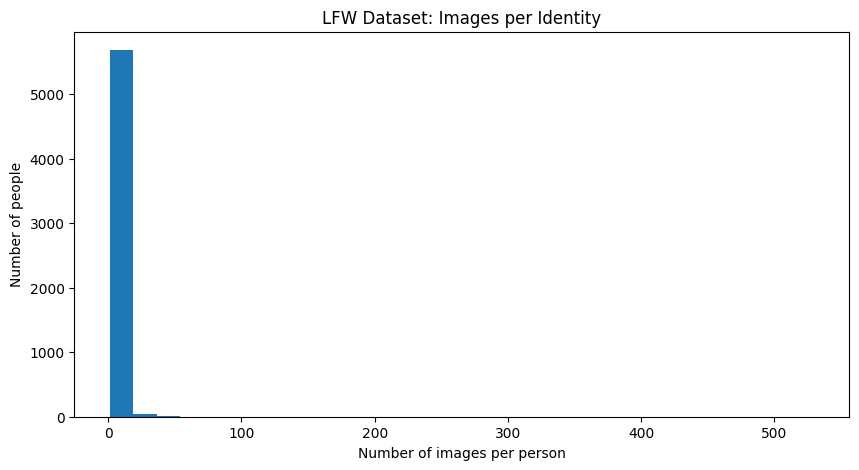

In [3]:
# visualize the distribution
plt.figure(figsize=(10, 5))

plt.hist(counts, bins=30)

plt.xlabel("Number of images per person")
plt.ylabel("Number of people")
plt.title("LFW Dataset: Images per Identity")

plt.show()

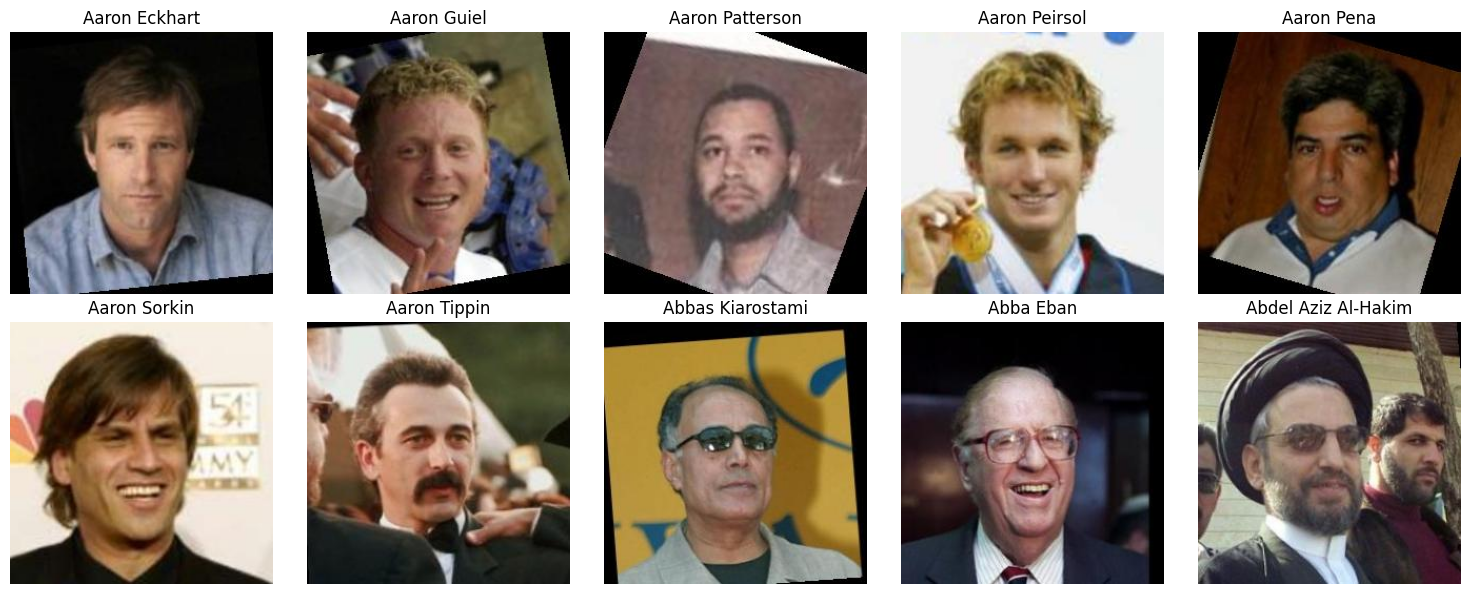

In [4]:
# display sample faces
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, person in zip(axes.ravel(), people[:10]):

    person_path = os.path.join(DATASET_PATH, person)

    images = [
        file for file in os.listdir(person_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_path = os.path.join(person_path, images[0])

    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(person.replace("_", " "))
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# inspect one image
sample_person = people[0]

sample_path = os.path.join(
    DATASET_PATH,
    sample_person
)

sample_image = [
    file for file in os.listdir(sample_path)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
][0]

image_path = os.path.join(sample_path, sample_image)

image = Image.open(image_path)

print("Person:", sample_person)
print("Image:", sample_image)
print("Image size:", image.size)
print("Image mode:", image.mode)

image_array = np.array(image)

print("Array shape:", image_array.shape)
print("Minimum pixel value:", image_array.min())
print("Maximum pixel value:", image_array.max())

Person: Aaron_Eckhart
Image: Aaron_Eckhart_0001.jpg
Image size: (250, 250)
Image mode: RGB
Array shape: (250, 250, 3)
Minimum pixel value: 0
Maximum pixel value: 239


In [6]:
# create a clean subset for our experiment
MIN_IMAGES = 20

selected_people = counts[counts >= MIN_IMAGES].index.tolist()

print("Total identities in original dataset:", len(people))
print("Identities with at least", MIN_IMAGES, "images:", len(selected_people))

print("\nSelected identities:")
print(selected_people[:20])

Total identities in original dataset: 5749
Identities with at least 20 images: 62

Selected identities:
['Alejandro_Toledo', 'Alvaro_Uribe', 'Amelie_Mauresmo', 'Andre_Agassi', 'Angelina_Jolie', 'Ariel_Sharon', 'Arnold_Schwarzenegger', 'Atal_Bihari_Vajpayee', 'Bill_Clinton', 'Carlos_Menem', 'Colin_Powell', 'David_Beckham', 'Donald_Rumsfeld', 'George_Robertson', 'George_W_Bush', 'Gerhard_Schroeder', 'Gloria_Macapagal_Arroyo', 'Gray_Davis', 'Guillermo_Coria', 'Hamid_Karzai']


In [7]:
NUM_CLASSES = 10

selected_people = (
    counts[counts >= MIN_IMAGES]
    .sort_values(ascending=False)
    .head(NUM_CLASSES)
    .index
    .tolist()
)

print("Final classes:", len(selected_people))

for person in selected_people:
    print(person, "→", counts[person], "images")

Final classes: 10
George_W_Bush → 530 images
Colin_Powell → 236 images
Tony_Blair → 144 images
Donald_Rumsfeld → 121 images
Gerhard_Schroeder → 109 images
Ariel_Sharon → 77 images
Hugo_Chavez → 71 images
Junichiro_Koizumi → 60 images
Jean_Chretien → 55 images
John_Ashcroft → 53 images


In [8]:
# import pytorch

import torch
import torchvision
import numpy as np

from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
Using device: cuda
GPU: NVIDIA GeForce RTX 2050


In [9]:
# create pytorch transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print(transform)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [10]:
# create our dataset
class LFWDataset(Dataset):

    def __init__(self, identity_dirs, selected_people, transform=None):

        self.samples = []
        self.transform = transform

        # Create label mapping
        self.class_to_idx = {
            person: idx
            for idx, person in enumerate(selected_people)
        }

        # Collect image paths and labels
        for person in selected_people:

            label = self.class_to_idx[person]

            for image_path in identity_dirs[person]:

                self.samples.append(
                    (image_path, label)
                )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):

        image_path, label = self.samples[index]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [11]:
# create dataset and dataloader
import os
import numpy as np

# --------------------------------------------------
# Rebuild image paths and identity mapping
# --------------------------------------------------

image_files = []

for root, dirs, files in os.walk(DATASET_ROOT):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_files.append(os.path.join(root, file))

identity_dirs = {}

for image_path in image_files:
    person_dir = os.path.dirname(image_path)
    person_name = os.path.basename(person_dir)

    identity_dirs.setdefault(person_name, []).append(image_path)

# Count images per identity
image_counts = {
    person: len(paths)
    for person, paths in identity_dirs.items()
}

# Select the same 10 identities
MIN_IMAGES = 20
NUM_CLASSES = 10

eligible_people = {
    person: count
    for person, count in image_counts.items()
    if count >= MIN_IMAGES
}

selected_people = sorted(
    eligible_people,
    key=lambda person: eligible_people[person],
    reverse=True
)[:NUM_CLASSES]

print("Total identities:", len(identity_dirs))
print("Total images:", len(image_files))

print("\nSelected identities:")
for i, person in enumerate(selected_people):
    print(
        f"{i}: {person} → {image_counts[person]} images"
    )

Total identities: 5749
Total images: 13233

Selected identities:
0: George_W_Bush → 530 images
1: Colin_Powell → 236 images
2: Tony_Blair → 144 images
3: Donald_Rumsfeld → 121 images
4: Gerhard_Schroeder → 109 images
5: Ariel_Sharon → 77 images
6: Hugo_Chavez → 71 images
7: Junichiro_Koizumi → 60 images
8: Jean_Chretien → 55 images
9: John_Ashcroft → 53 images


In [12]:
# ============================================
# Create PyTorch Dataset + DataLoader
# ============================================

from PIL import Image
from torch.utils.data import Dataset, DataLoader


class LFWDataset(Dataset):

    def __init__(self, identity_dirs, selected_people, transform=None):

        self.samples = []
        self.transform = transform

        # Map person name → numeric label
        self.class_to_idx = {
            person: idx
            for idx, person in enumerate(selected_people)
        }

        # Collect image paths and labels
        for person in selected_people:

            label = self.class_to_idx[person]

            for image_path in identity_dirs[person]:

                self.samples.append(
                    (image_path, label)
                )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):

        image_path, label = self.samples[index]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


# --------------------------------------------
# Create dataset
# --------------------------------------------

dataset = LFWDataset(
    identity_dirs=identity_dirs,
    selected_people=selected_people,
    transform=transform
)

print("Dataset created successfully!")
print("Total samples:", len(dataset))
print("Number of classes:", len(selected_people))


# --------------------------------------------
# Create DataLoader
# --------------------------------------------

BATCH_SIZE = 32

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("DataLoader created successfully!")


# --------------------------------------------
# Test one batch
# --------------------------------------------

images, labels = next(iter(loader))

print("\nBatch information:")
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 5 labels:", labels[:5].tolist())

Dataset created successfully!
Total samples: 1456
Number of classes: 10
DataLoader created successfully!

Batch information:
Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
First 5 labels: [0, 0, 0, 0, 0]


In [13]:
# create the dataloader
BATCH_SIZE = 32

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

images, labels = next(iter(loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])


In [14]:
# load pretrained ResNet-50
weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [15]:
# Remove the classification head
model.fc = nn.Identity()

model = model.to(device)

model.eval()

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [16]:
# extract one embedding
image, label = dataset[0]

# Add batch dimension
image = image.unsqueeze(0)

# Move to CPU/GPU
image = image.to(device)

with torch.no_grad():

    embedding = model(image)

print("Input shape:", image.shape)
print("Embedding shape:", embedding.shape)
print("Embedding length:", embedding.shape[1])

print("\nFirst 10 values:")
print(embedding[0][:10])

Input shape: torch.Size([1, 3, 224, 224])
Embedding shape: torch.Size([1, 2048])
Embedding length: 2048

First 10 values:
tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.2304, 0.0000, 0.0000, 0.3876, 0.0000,
        0.0000], device='cuda:0')


In [17]:
# extract embeddings for the entire dataset
from tqdm import tqdm

all_embeddings = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in tqdm(
        loader,
        desc="Extracting embeddings"
    ):

        images = images.to(device)

        embeddings = model(images)

        all_embeddings.append(
            embeddings.cpu().numpy()
        )

        all_labels.append(
            labels.numpy()
        )

# Combine batches
X = np.concatenate(all_embeddings, axis=0)
y = np.concatenate(all_labels, axis=0)

print("\nFinished!")

print("X shape:", X.shape)
print("y shape:", y.shape)

Extracting embeddings: 100%|██████████| 46/46 [00:12<00:00,  3.55it/s]


Finished!
X shape: (1456, 2048)
y shape: (1456,)


In [18]:
# verify our embeddings
print("Embedding matrix:")
print("Samples:", X.shape[0])
print("Features per sample:", X.shape[1])

print("\nLabels:")
print("Number of labels:", len(y))
print("Unique labels:", np.unique(y))

print("\nClass mapping:")

for idx, person in enumerate(selected_people):
    count = np.sum(y == idx)

    print(
        f"{idx}: {person:30s} → {count} images"
    )

Embedding matrix:
Samples: 1456
Features per sample: 2048

Labels:
Number of labels: 1456
Unique labels: [0 1 2 3 4 5 6 7 8 9]

Class mapping:
0: George_W_Bush                  → 530 images
1: Colin_Powell                   → 236 images
2: Tony_Blair                     → 144 images
3: Donald_Rumsfeld                → 121 images
4: Gerhard_Schroeder              → 109 images
5: Ariel_Sharon                   → 77 images
6: Hugo_Chavez                    → 71 images
7: Junichiro_Koizumi              → 60 images
8: Jean_Chretien                  → 55 images
9: John_Ashcroft                  → 53 images


In [19]:
# save the embeddings
np.save("X_embeddings_resnet50.npy", X)
np.save("y_labels.npy", y)
np.save(
    "selected_people.npy",
    np.array(selected_people)
)

print("Embeddings saved successfully!")

print("X_embeddings_resnet50.npy")
print("y_labels.npy")
print("selected_people.npy")

Embeddings saved successfully!
X_embeddings_resnet50.npy
y_labels.npy
selected_people.npy


In [20]:
# verify our embeddings
import numpy as np

print("Embedding matrix shape:", X.shape)
print("Label vector shape:", y.shape)

print("\nNumber of samples:", len(X))
print("Embedding dimensions:", X.shape[1])
print("Number of classes:", len(np.unique(y)))

print("\nClass distribution:")

for label in np.unique(y):
    count = np.sum(y == label)
    print(
        f"{label}: {selected_people[label]:30s} → {count} images"
    )

Embedding matrix shape: (1456, 2048)
Label vector shape: (1456,)

Number of samples: 1456
Embedding dimensions: 2048
Number of classes: 10

Class distribution:
0: George_W_Bush                  → 530 images
1: Colin_Powell                   → 236 images
2: Tony_Blair                     → 144 images
3: Donald_Rumsfeld                → 121 images
4: Gerhard_Schroeder              → 109 images
5: Ariel_Sharon                   → 77 images
6: Hugo_Chavez                    → 71 images
7: Junichiro_Koizumi              → 60 images
8: Jean_Chretien                  → 55 images
9: John_Ashcroft                  → 53 images


In [21]:
# normalize the embeddings
from sklearn.preprocessing import normalize

X_normalized = normalize(X, norm="l2")

print("Original shape:", X.shape)
print("Normalized shape:", X_normalized.shape)

print("\nFirst embedding norm:")
print(np.linalg.norm(X_normalized[0]))

Original shape: (1456, 2048)
Normalized shape: (1456, 2048)

First embedding norm:
0.99999994


In [22]:
# train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_normalized,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training samples: 1164
Testing samples: 292

Training shape: (1164, 2048)
Testing shape: (292, 2048)


In [23]:
# train the svm
from sklearn.svm import SVC

classifier = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=True,
    random_state=42
)

print("Training SVM...")

classifier.fit(
    X_train,
    y_train
)

print("Training completed!")

Training SVM...
Training completed!


In [24]:
# make predictions
y_pred = classifier.predict(X_test)

print("Predictions generated!")

print("\nFirst 20 predictions:")

for actual, predicted in zip(
    y_test[:20],
    y_pred[:20]
):

    actual_name = selected_people[actual]
    predicted_name = selected_people[predicted]

    print(
        f"Actual: {actual_name:30s} "
        f"| Predicted: {predicted_name}"
    )

Predictions generated!

First 20 predictions:
Actual: George_W_Bush                  | Predicted: George_W_Bush
Actual: Jean_Chretien                  | Predicted: Jean_Chretien
Actual: George_W_Bush                  | Predicted: George_W_Bush
Actual: George_W_Bush                  | Predicted: George_W_Bush
Actual: George_W_Bush                  | Predicted: George_W_Bush
Actual: George_W_Bush                  | Predicted: George_W_Bush
Actual: Tony_Blair                     | Predicted: Colin_Powell
Actual: John_Ashcroft                  | Predicted: Donald_Rumsfeld
Actual: George_W_Bush                  | Predicted: George_W_Bush
Actual: Colin_Powell                   | Predicted: Colin_Powell
Actual: George_W_Bush                  | Predicted: George_W_Bush
Actual: George_W_Bush                  | Predicted: George_W_Bush
Actual: Colin_Powell                   | Predicted: Colin_Powell
Actual: Hugo_Chavez                    | Predicted: Colin_Powell
Actual: George_W_Bush           

In [25]:
# calculate accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Recognition Accuracy: {accuracy * 100:.2f}%"
)

Recognition Accuracy: 72.60%


In [26]:
# save the recognition model
import joblib

joblib.dump(
    classifier,
    "face_recognition_svm.pkl"
)

joblib.dump(
    selected_people,
    "face_classes.pkl"
)

print("Recognition model saved!")
print("→ face_recognition_svm.pkl")
print("→ face_classes.pkl")

Recognition model saved!
→ face_recognition_svm.pkl
→ face_classes.pkl


In [27]:
# classification report
from sklearn.metrics import (
    classification_report,
    accuracy_score
)

report = classification_report(
    y_test,
    y_pred,
    target_names=selected_people,
    digits=3
)

print(report)

                   precision    recall  f1-score   support

    George_W_Bush      0.779     0.962     0.861       106
     Colin_Powell      0.635     0.851     0.727        47
       Tony_Blair      0.704     0.655     0.679        29
  Donald_Rumsfeld      0.647     0.458     0.537        24
Gerhard_Schroeder      0.579     0.500     0.537        22
     Ariel_Sharon      1.000     0.562     0.720        16
      Hugo_Chavez      0.889     0.571     0.696        14
Junichiro_Koizumi      1.000     0.250     0.400        12
    Jean_Chretien      1.000     0.545     0.706        11
    John_Ashcroft      0.375     0.273     0.316        11

         accuracy                          0.726       292
        macro avg      0.761     0.563     0.618       292
     weighted avg      0.742     0.726     0.709       292



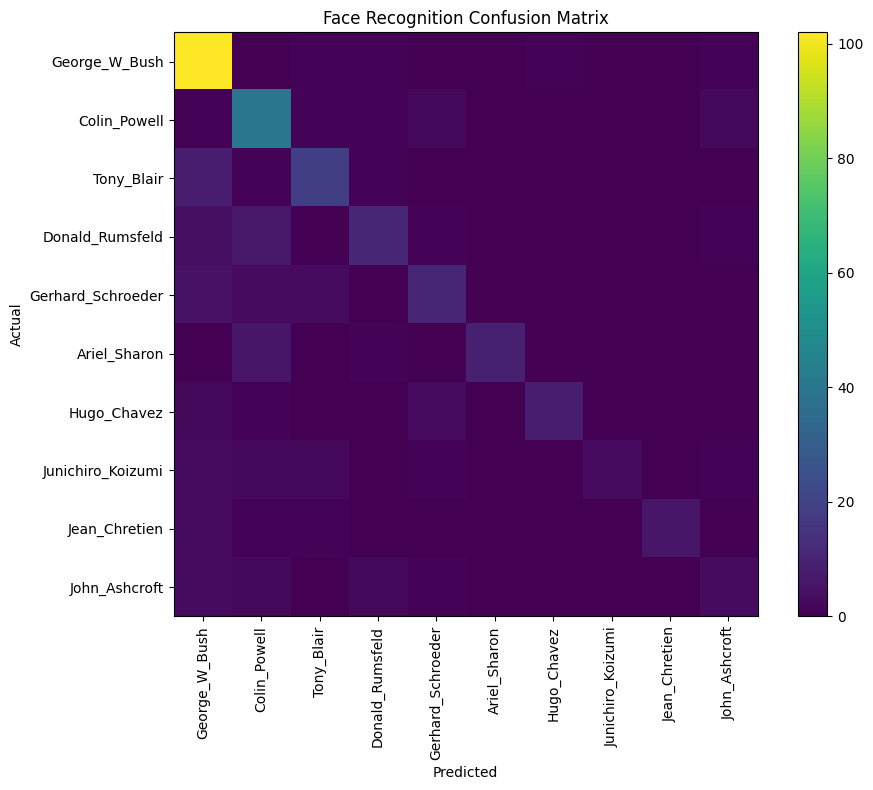

In [28]:
# cofusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    range(len(selected_people)),
    selected_people,
    rotation=90
)

plt.yticks(
    range(len(selected_people)),
    selected_people
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Face Recognition Confusion Matrix")

plt.tight_layout()
plt.show()

In [29]:
# per-class accuracy
print("Per-class accuracy")
print("=" * 50)

for label, person in enumerate(selected_people):

    mask = y_test == label

    class_accuracy = np.mean(
        y_pred[mask] == y_test[mask]
    )

    print(
        f"{person:30s} → "
        f"{class_accuracy * 100:.2f}%"
    )

Per-class accuracy
George_W_Bush                  → 96.23%
Colin_Powell                   → 85.11%
Tony_Blair                     → 65.52%
Donald_Rumsfeld                → 45.83%
Gerhard_Schroeder              → 50.00%
Ariel_Sharon                   → 56.25%
Hugo_Chavez                    → 57.14%
Junichiro_Koizumi              → 25.00%
Jean_Chretien                  → 54.55%
John_Ashcroft                  → 27.27%


In [30]:
# prediction probabilites
y_prob = classifier.predict_proba(X_test)

print("Probability matrix shape:", y_prob.shape)

print("\nFirst prediction:")
print("Actual:", selected_people[y_test[0]])
print("Predicted:", selected_people[y_pred[0]])

print("\nClass probabilities:")

for class_idx, probability in enumerate(y_prob[0]):

    print(
        f"{selected_people[class_idx]:30s}"
        f"{probability * 100:.2f}%"
    )

Probability matrix shape: (292, 10)

First prediction:
Actual: George_W_Bush
Predicted: George_W_Bush

Class probabilities:
George_W_Bush                 96.77%
Colin_Powell                  0.41%
Tony_Blair                    0.32%
Donald_Rumsfeld               0.36%
Gerhard_Schroeder             0.14%
Ariel_Sharon                  0.20%
Hugo_Chavez                   0.20%
Junichiro_Koizumi             0.21%
Jean_Chretien                 1.16%
John_Ashcroft                 0.22%


In [31]:
# find incorrect predictions
wrong_indices = np.where(
    y_pred != y_test
)[0]

print(
    "Incorrect predictions:",
    len(wrong_indices)
)

print(
    "Total test samples:",
    len(y_test)
)

print(
    "Error rate:",
    len(wrong_indices) / len(y_test) * 100,
    "%"
)

Incorrect predictions: 80
Total test samples: 292
Error rate: 27.397260273972602 %


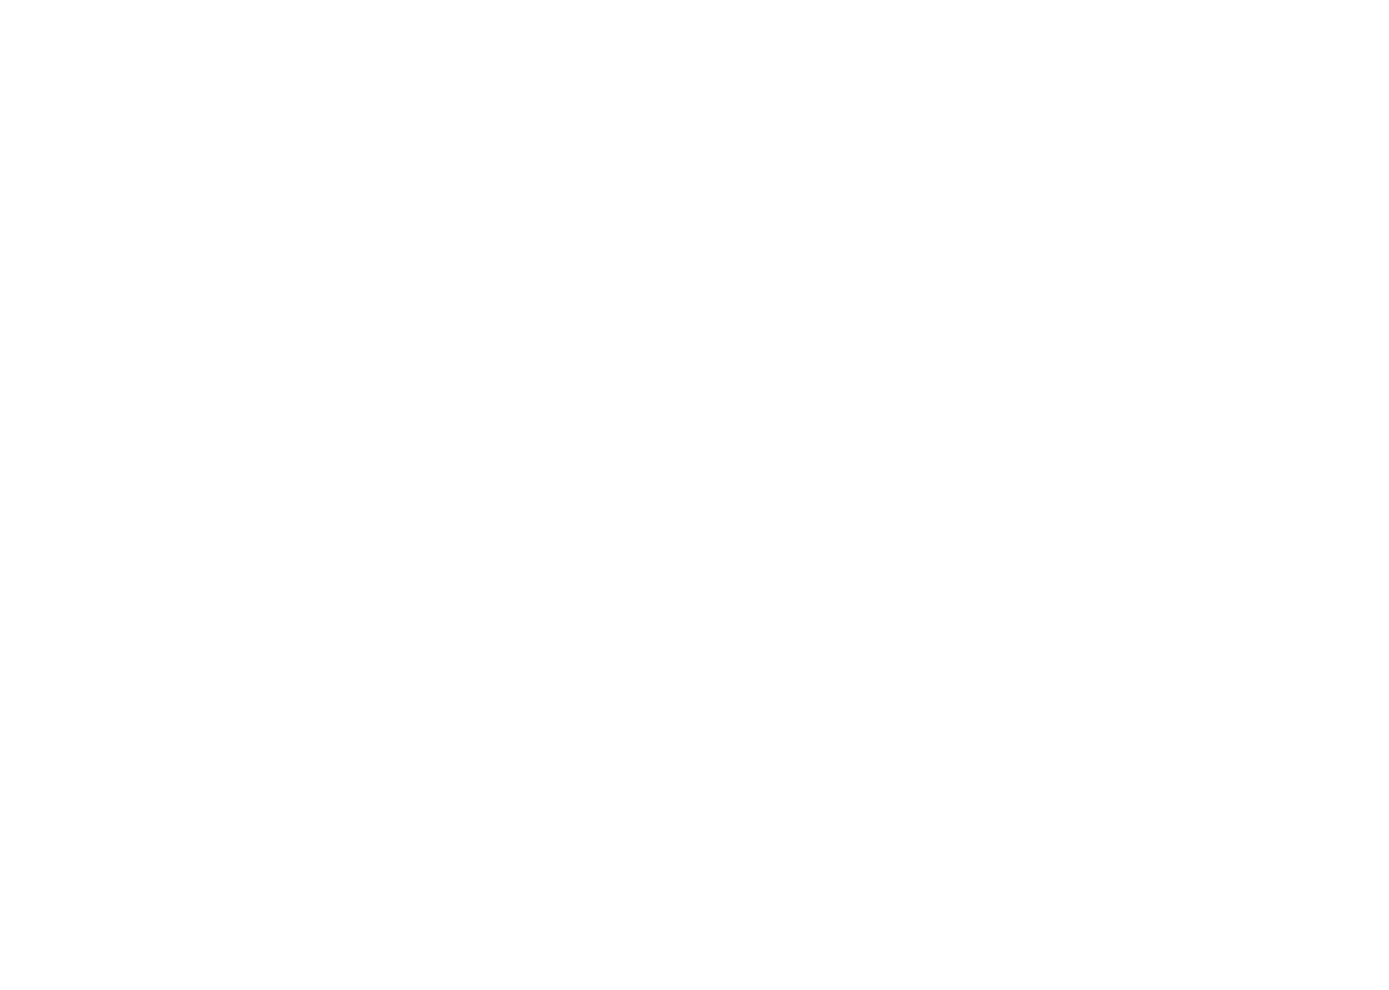

In [32]:
# display incorrect predictions
import random

# Show up to 12 incorrect examples
num_examples = min(12, len(wrong_indices))

selected_wrong = random.sample(
    list(wrong_indices),
    num_examples
)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(14, 10)
)

for ax, idx in zip(
    axes.ravel(),
    selected_wrong
):

    image_path = dataset.samples[
        # We need to map the test sample back later
        0
    ][0]

    ax.axis("off")

plt.tight_layout()
plt.show()

In [33]:
# correct visual error analysis
# Create indices for the original dataset
indices = np.arange(len(X_normalized))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Verify that this produces the same split
print("Training indices:", len(train_idx))
print("Testing indices:", len(test_idx))

# Get image paths corresponding to test samples
test_image_paths = [
    dataset.samples[i][0]
    for i in test_idx
]

# Find incorrect predictions
wrong_indices = np.where(
    y_pred != y_test
)[0]

print("Incorrect predictions:", len(wrong_indices))

Training indices: 1164
Testing indices: 292
Incorrect predictions: 80


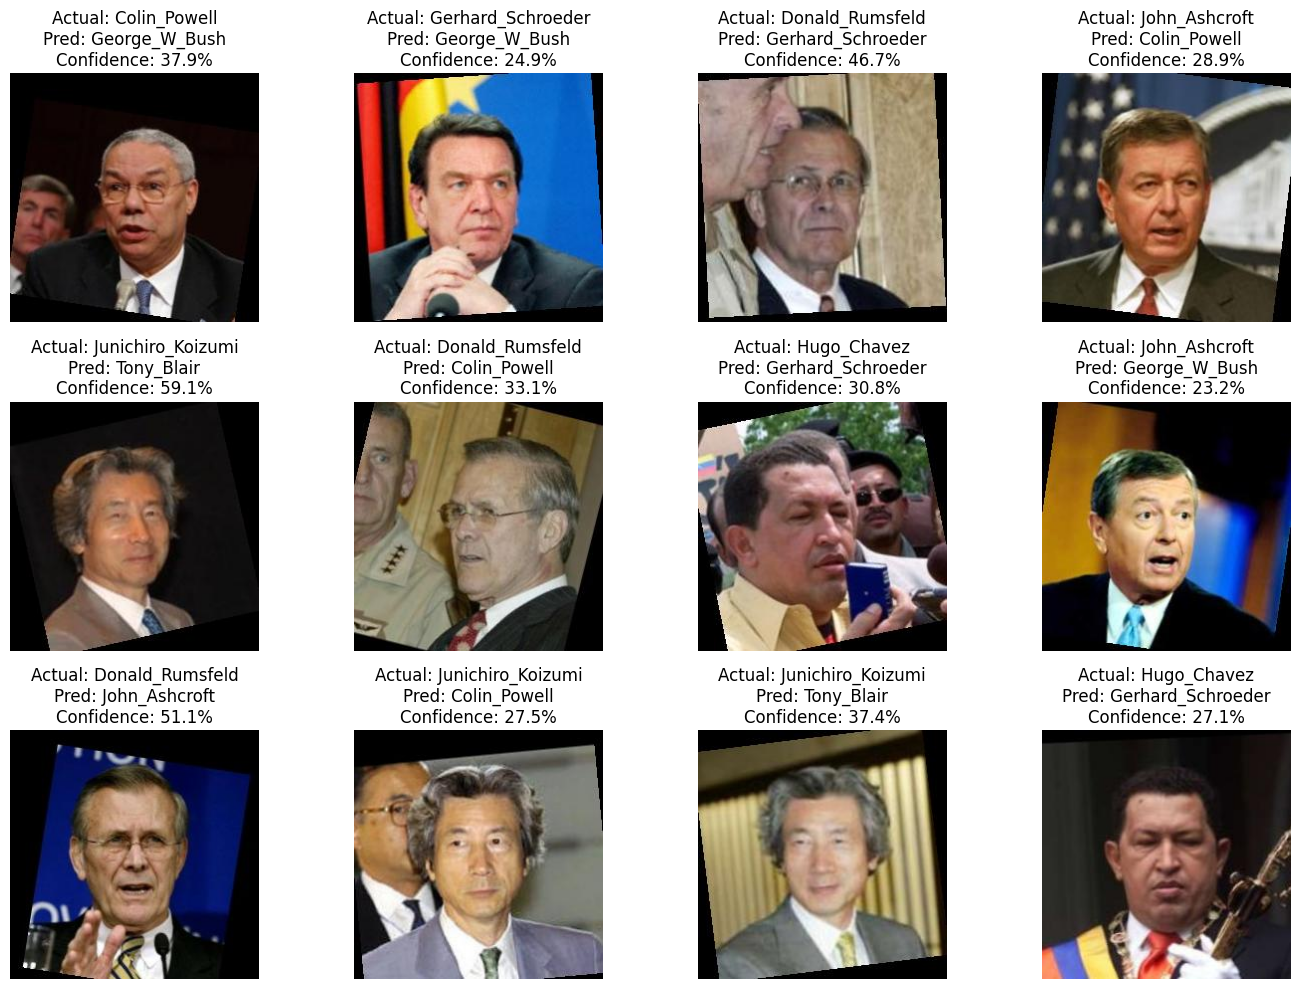

In [34]:
# visualize mistake
import random
from PIL import Image

num_examples = min(12, len(wrong_indices))

selected_wrong = random.sample(
    list(wrong_indices),
    num_examples
)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(14, 10)
)

for ax, test_position in zip(
    axes.ravel(),
    selected_wrong
):

    image_path = test_image_paths[test_position]

    image = Image.open(image_path)

    actual = selected_people[
        y_test[test_position]
    ]

    predicted = selected_people[
        y_pred[test_position]
    ]

    confidence = y_prob[
        test_position
    ][y_pred[test_position]]

    ax.imshow(image)

    ax.set_title(
        f"Actual: {actual}\n"
        f"Pred: {predicted}\n"
        f"Confidence: {confidence:.1%}"
    )

    ax.axis("off")

# Hide unused axes
for ax in axes.ravel()[num_examples:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [35]:
# extract embedding
def extract_embedding(image_path):
    """
    Convert an image into a 2048-dimensional
    ResNet-50 embedding.
    """

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Apply the same preprocessing used during training
    image_tensor = transform(image)

    # Add batch dimension
    image_tensor = image_tensor.unsqueeze(0)

    # Move to CPU/GPU
    image_tensor = image_tensor.to(device)

    # Extract embedding
    model.eval()

    with torch.no_grad():
        embedding = model(image_tensor)

    # Move back to CPU and convert to NumPy
    embedding = embedding.cpu().numpy().flatten()

    return embedding


print("extract_embedding() is ready!")

extract_embedding() is ready!


In [36]:
# test the helper first
test_person = selected_people[0]

test_image = identity_dirs[
    test_person
][0]

embedding = extract_embedding(test_image)

print("Person:", test_person)
print("Embedding shape:", embedding.shape)
print("Embedding dimensions:", len(embedding))

Person: George_W_Bush
Embedding shape: (2048,)
Embedding dimensions: 2048


In [37]:
# build the recognition function
def recognize_face(image_path):

    # Extract CNN embedding
    embedding = extract_embedding(image_path)

    # Normalize
    embedding = embedding / (
        np.linalg.norm(embedding) + 1e-10
    )

    # Reshape for classifier
    embedding = embedding.reshape(1, -1)

    # Predict
    prediction = classifier.predict(
        embedding
    )[0]

    # Probability
    probabilities = classifier.predict_proba(
        embedding
    )[0]

    confidence = probabilities[prediction]

    person = selected_people[prediction]

    return person, confidence

In [38]:
# test the function
test_person = selected_people[0]

test_image = identity_dirs[
    test_person
][0]

person, confidence = recognize_face(
    test_image
)

print("Actual person:", test_person)
print("Predicted person:", person)
print(
    f"Confidence: {confidence * 100:.2f}%"
)

Actual person: George_W_Bush
Predicted person: George_W_Bush
Confidence: 92.21%


# stage 5

In [39]:
# If OpenCV is not installed, uncomment:
# !pip install opencv-python

import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV version:", cv2.__version__)

OpenCV version: 4.12.0


In [40]:
# load the face detector
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

if face_cascade.empty():
    raise RuntimeError("Could not load face detector!")

print("Face detector loaded successfully!")

Face detector loaded successfully!


In [41]:
# test face detection
test_person = selected_people[0]

test_image_path = identity_dirs[
    test_person
][0]

image = cv2.imread(test_image_path)

# OpenCV loads BGR
gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

print("Image:", test_image_path)
print("Faces detected:", len(faces))
print("Bounding boxes:", faces)

Image: E:\Pyhton code\Data Sets\archive\labeled wild face dataset 13000 images\lfw-deepfunneled\lfw-deepfunneled\George_W_Bush\George_W_Bush_0001.jpg
Faces detected: 1
Bounding boxes: [[ 70  65 115 115]]


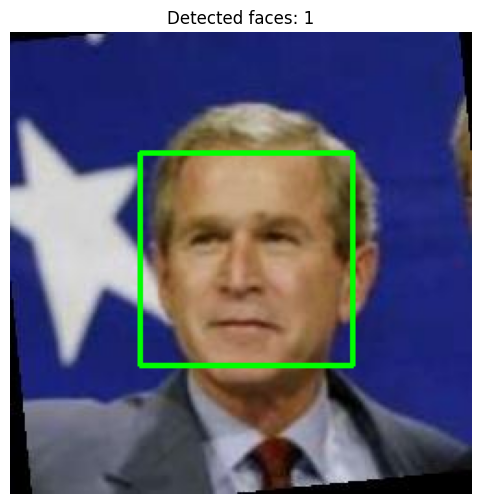

In [42]:
# visualize the detected face
image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

display_image = image_rgb.copy()

for (x, y_box, w, h) in faces:

    cv2.rectangle(
        display_image,
        (x, y_box),
        (x + w, y_box + h),
        (0, 255, 0),
        2
    )

plt.figure(figsize=(6, 6))

plt.imshow(display_image)
plt.axis("off")
plt.title(
    f"Detected faces: {len(faces)}"
)

plt.show()

In [43]:
# create the complete recognition pipeline
def recognize_faces_in_image(image_path):
    """
    Detect faces in an image and recognize
    each detected face using ResNet-50 + SVM.
    """

    image = cv2.imread(image_path)

    if image is None:
        raise ValueError(
            f"Could not read image: {image_path}"
        )

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    # Detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    results = []

    for (x, y_box, w, h) in faces:

        # Crop face
        face = image[
            y_box:y_box+h,
            x:x+w
        ]

        # Convert BGR → RGB
        face_rgb = cv2.cvtColor(
            face,
            cv2.COLOR_BGR2RGB
        )

        # Convert to PIL
        face_pil = Image.fromarray(
            face_rgb
        )

        # Apply same preprocessing as ResNet
        face_tensor = transform(face_pil)

        # Add batch dimension
        face_tensor = face_tensor.unsqueeze(0)

        # Move to device
        face_tensor = face_tensor.to(device)

        # CNN embedding
        model.eval()

        with torch.no_grad():
            embedding = model(face_tensor)

        embedding = (
            embedding
            .cpu()
            .numpy()
            .flatten()
        )

        # L2 normalization
        embedding = embedding / (
            np.linalg.norm(embedding) + 1e-10
        )

        # SVM prediction
        prediction = classifier.predict(
            embedding.reshape(1, -1)
        )[0]

        probabilities = classifier.predict_proba(
            embedding.reshape(1, -1)
        )[0]

        confidence = probabilities[prediction]

        person = selected_people[prediction]

        results.append({
            "box": (x, y_box, w, h),
            "person": person,
            "confidence": confidence
        })

    return image, results

In [44]:
# test the complete pipeline
image, results = recognize_faces_in_image(
    test_image_path
)

print("Detected faces:", len(results))

for result in results:

    print(
        f"Person: {result['person']}"
    )

    print(
        f"Confidence: "
        f"{result['confidence'] * 100:.2f}%"
    )

    print(
        f"Bounding box: "
        f"{result['box']}"
    )

Detected faces: 1
Person: Tony_Blair
Confidence: 59.60%
Bounding box: (np.int32(70), np.int32(65), np.int32(115), np.int32(115))


In [45]:
# add a confidence threshold
CONFIDENCE_THRESHOLD = 0.70


def recognize_faces_with_threshold(image_path):

    image, results = recognize_faces_in_image(
        image_path
    )

    for result in results:

        if result["confidence"] < CONFIDENCE_THRESHOLD:

            result["person"] = "Unknown"

    return image, results


print(
    f"Confidence threshold: "
    f"{CONFIDENCE_THRESHOLD * 100:.0f}%"
)

Confidence threshold: 70%


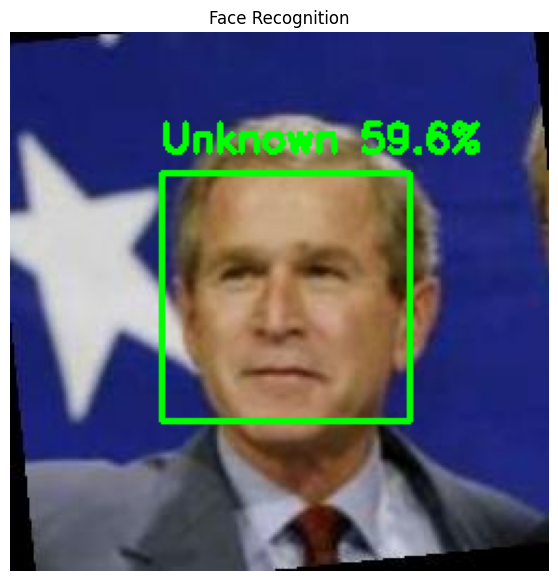

In [46]:
# draw predictions on an image
def draw_results(image, results):

    output = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    for result in results:

        x, y_box, w, h = result["box"]

        person = result["person"]

        confidence = result["confidence"]

        # Draw bounding box
        cv2.rectangle(
            output,
            (x, y_box),
            (x + w, y_box + h),
            (0, 255, 0),
            2
        )

        # Label
        label = (
            f"{person} "
            f"{confidence * 100:.1f}%"
        )

        cv2.putText(
            output,
            label,
            (x, max(y_box - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

    return output


image, results = recognize_faces_with_threshold(
    test_image_path
)

output = draw_results(
    image,
    results
)

plt.figure(figsize=(7, 7))

plt.imshow(output)
plt.axis("off")
plt.title("Face Recognition")

plt.show()

# stage 6- Training on my image

In [48]:
from pathlib import Path

MY_FACE_DIR = Path(r"E:\Pyhton code\Deep Learning\CNN\Face Recognition Model\my face")

my_face_images = sorted([
    p for p in MY_FACE_DIR.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
])

print("My face images:", len(my_face_images))

for image_path in my_face_images:
    print(image_path.name)

My face images: 27
.trashed-1789463650-IMG_20260815_145422508_HDR_PORTRAIT (1).jpg
.trashed-1789535108-IMG_20260815_145422508_HDR_PORTRAIT.jpg
.trashed-1789535121-IMG_20260815_145419256_HDR.jpg
.trashed-1789535169-IMG_20260815_143142359_HDR (1).jpg
.trashed-1789535173-IMG_20260815_143126528_HDR (1).jpg
.trashed-1789535187-IMG_20260815_145440350_PORTRAIT.jpg
IMG-20220911-WA0010.jpg
IMG-20220911-WA0017.jpg
IMG-20250109-WA0039.jpg
IMG-20250109-WA0041.jpg
IMG-20250109-WA0043.jpg
IMG-20250109-WA0049.jpg
IMG-20250109-WA0051.jpg
IMG-20250419-WA0014.jpg
IMG-20250419-WA0022.jpg
img.png
IMG_20220913_194353.jpg
IMG_20240208_175105.jpg
IMG_20240218_155132.jpg
IMG_20250109_132901.jpg
IMG_20250109_140132.jpg
IMG_20250110_081137.jpg
IMG_20251016_171504.jpg
IMG_20260815_145436175_HDR_PORTRAIT (1) (1).jpg
Screenshot_20260802-205652.png
Suyash....jpg
WhatsApp Image 2025-01-14 at 14.07.29_a0a088ae.jpg


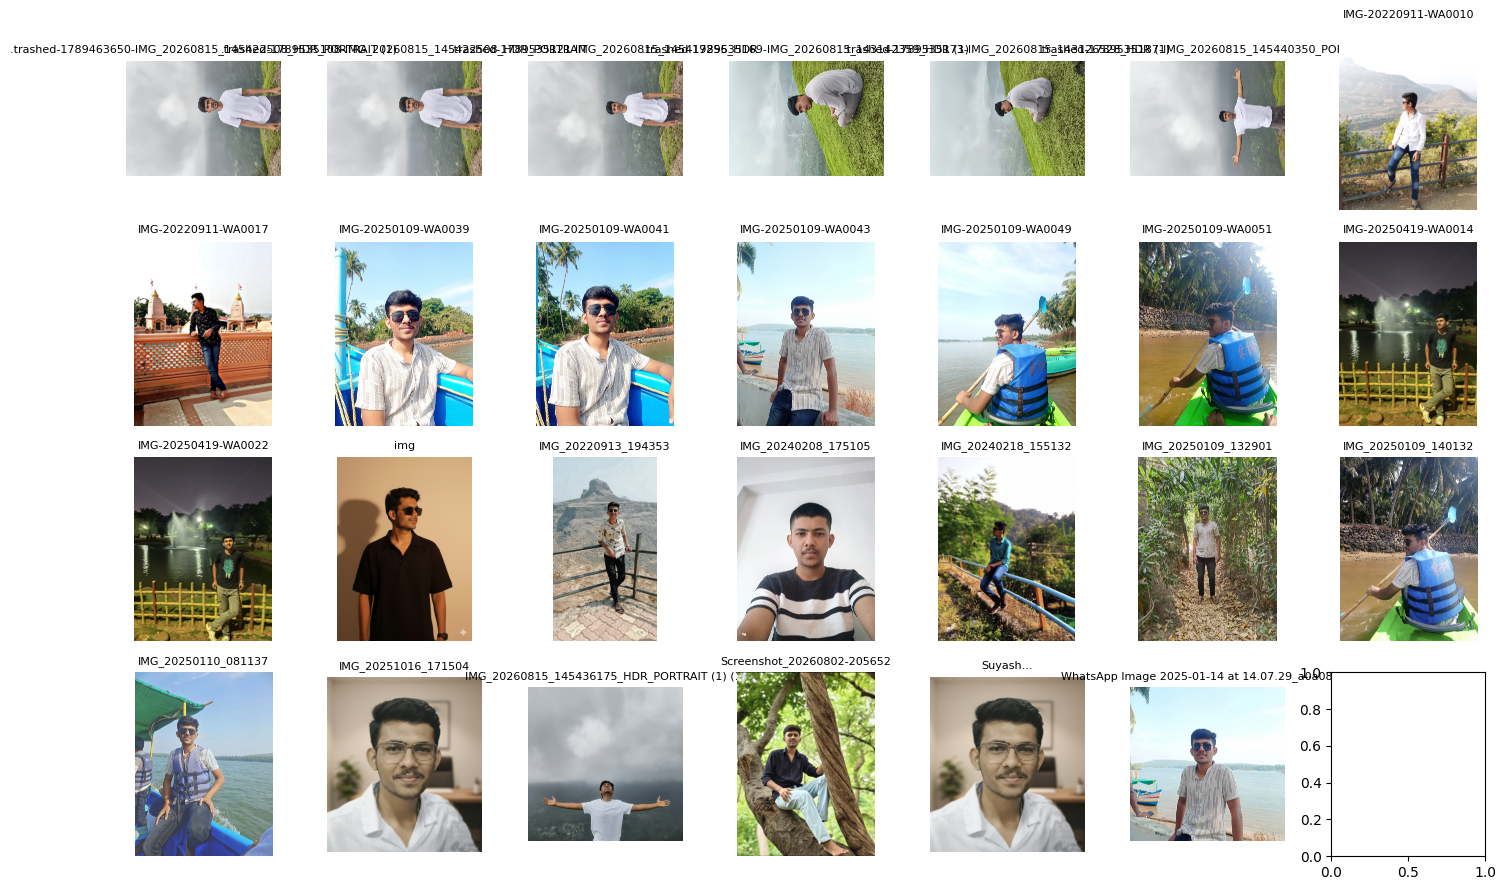

In [49]:
# visually inspect your images
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(
    4,
    7,
    figsize=(14, 9)
)

for ax, image_path in zip(
    axes.ravel(),
    my_face_images
):

    image = Image.open(image_path).convert("RGB")

    ax.imshow(image)

    ax.set_title(
        image_path.stem,
        fontsize=8
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [50]:
# create train/test split
from sklearn.model_selection import train_test_split

my_face_train, my_face_test = train_test_split(
    my_face_images,
    test_size=0.25,
    random_state=42
)

print("Training images:", len(my_face_train))
print("Testing images:", len(my_face_test))

print("\nTraining:")
for p in my_face_train:
    print(p.name)

print("\nTesting:")
for p in my_face_test:
    print(p.name)

Training images: 20
Testing images: 7

Training:
IMG_20240208_175105.jpg
IMG-20250109-WA0051.jpg
Screenshot_20260802-205652.png
.trashed-1789535108-IMG_20260815_145422508_HDR_PORTRAIT.jpg
.trashed-1789535173-IMG_20260815_143126528_HDR (1).jpg
.trashed-1789535187-IMG_20260815_145440350_PORTRAIT.jpg
.trashed-1789535121-IMG_20260815_145419256_HDR.jpg
img.png
IMG_20251016_171504.jpg
.trashed-1789535169-IMG_20260815_143142359_HDR (1).jpg
Suyash....jpg
IMG_20260815_145436175_HDR_PORTRAIT (1) (1).jpg
IMG_20240218_155132.jpg
WhatsApp Image 2025-01-14 at 14.07.29_a0a088ae.jpg
IMG_20250109_140132.jpg
IMG-20220911-WA0017.jpg
IMG-20250109-WA0043.jpg
IMG-20250419-WA0022.jpg
IMG_20250109_132901.jpg
IMG-20220911-WA0010.jpg

Testing:
IMG-20250109-WA0039.jpg
IMG-20250419-WA0014.jpg
IMG-20250109-WA0041.jpg
IMG_20250110_081137.jpg
.trashed-1789463650-IMG_20260815_145422508_HDR_PORTRAIT (1).jpg
IMG-20250109-WA0049.jpg
IMG_20220913_194353.jpg


In [51]:
# create augmentation transform
from torchvision import transforms

train_augmentation = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),

    transforms.RandomResizedCrop(
        size=224,
        scale=(0.85, 1.0)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# IMPORTANT:
# No augmentation for test images

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Training augmentation ready.")
print("Test transform ready.")

Training augmentation ready.
Test transform ready.


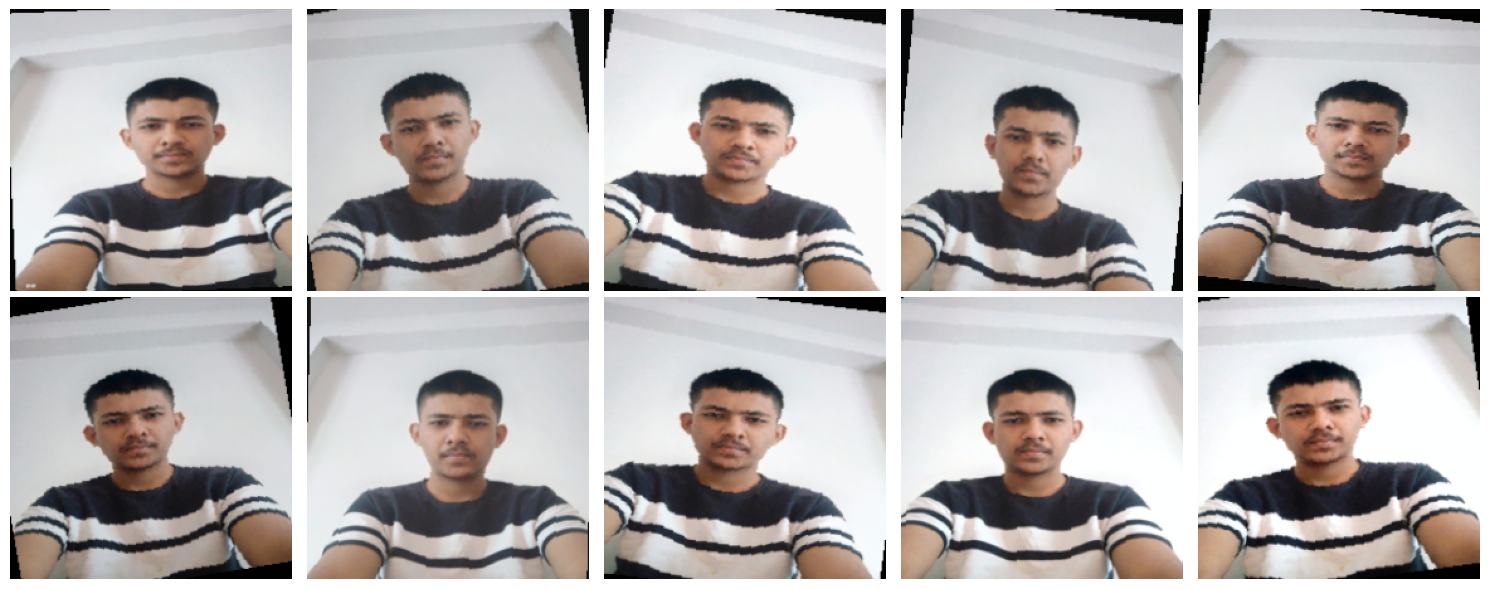

In [52]:
# visualize augmentation
sample_image = Image.open(
    my_face_train[0]
).convert("RGB")

fig, axes = plt.subplots(
    2,
    5,
    figsize=(15, 6)
)

for ax in axes.ravel():

    augmented = train_augmentation(
        sample_image
    )

    # Undo normalization for visualization
    augmented = augmented.permute(
        1, 2, 0
    ).numpy()

    mean = np.array(
        [0.485, 0.456, 0.406]
    )

    std = np.array(
        [0.229, 0.224, 0.225]
    )

    augmented = (
        augmented * std + mean
    )

    augmented = np.clip(
        augmented,
        0,
        1
    )

    ax.imshow(augmented)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [53]:
# Check that our existing embedding pipeline is still available

print("Checking embedding pipeline...")

print("extract_embedding:", callable(extract_embedding))

print("Number of training images:", len(my_face_train))
print("Number of testing images:", len(my_face_test))

Checking embedding pipeline...
extract_embedding: True
Number of training images: 20
Number of testing images: 7


In [54]:
# create a temporary augmentation directory
from pathlib import Path
import shutil

AUGMENTED_DIR = Path("my_face_augmented")

# Remove previous augmented data if it exists
if AUGMENTED_DIR.exists():
    shutil.rmtree(AUGMENTED_DIR)

AUGMENTED_DIR.mkdir()

print("Augmented image directory created:")
print(AUGMENTED_DIR.resolve())

Augmented image directory created:
E:\Pyhton code\Deep Learning\CNN\Face Recognition Model\my_face_augmented


In [55]:
# generate augmented images
from PIL import Image

AUGMENTATIONS_PER_IMAGE = 5

augmented_paths = []

for image_path in my_face_train:

    image = Image.open(image_path).convert("RGB")

    for i in range(AUGMENTATIONS_PER_IMAGE):

        augmented_tensor = train_augmentation(image)

        # Convert normalized tensor back to normal image
        augmented_array = augmented_tensor.permute(
            1, 2, 0
        ).numpy()

        mean = np.array(
            [0.485, 0.456, 0.406]
        )

        std = np.array(
            [0.229, 0.224, 0.225]
        )

        augmented_array = (
            augmented_array * std + mean
        )

        augmented_array = np.clip(
            augmented_array,
            0,
            1
        )

        augmented_image = Image.fromarray(
            (augmented_array * 255).astype(np.uint8)
        )

        output_path = (
            AUGMENTED_DIR /
            f"{image_path.stem}_aug_{i+1}.jpg"
        )

        augmented_image.save(output_path)

        augmented_paths.append(output_path)

print("Original training images:", len(my_face_train))
print("Augmented images:", len(augmented_paths))
print(
    "Total training images:",
    len(my_face_train) + len(augmented_paths)
)

Original training images: 20
Augmented images: 100
Total training images: 120


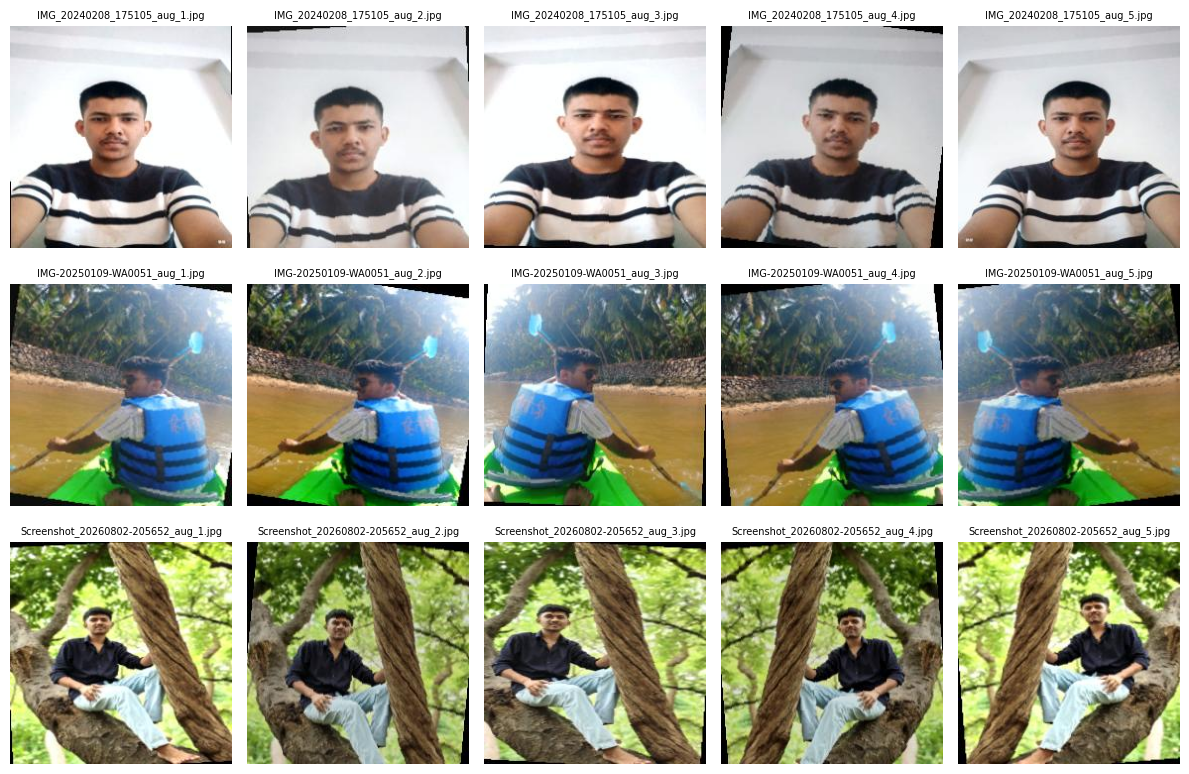

In [56]:
# visualize at some generated images
fig, axes = plt.subplots(
    3,
    5,
    figsize=(12, 8)
)

for ax, image_path in zip(
    axes.ravel(),
    augmented_paths[:15]
):

    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(image_path.name, fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [57]:
# generate embeddings for your original training
print("Generating embeddings for original training images...")

my_original_embeddings = []

for image_path in my_face_train:

    embedding = extract_embedding(
        str(image_path)
    )

    my_original_embeddings.append(
        embedding
    )

my_original_embeddings = np.array(
    my_original_embeddings
)

print(
    "Original embedding shape:",
    my_original_embeddings.shape
)

Generating embeddings for original training images...
Original embedding shape: (20, 2048)


In [58]:
# generate embeddings for augmentated images
print("Generating embeddings for augmented images...")

my_augmented_embeddings = []

for image_path in augmented_paths:

    embedding = extract_embedding(
        str(image_path)
    )

    my_augmented_embeddings.append(
        embedding
    )

my_augmented_embeddings = np.array(
    my_augmented_embeddings
)

print(
    "Augmented embedding shape:",
    my_augmented_embeddings.shape
)

Generating embeddings for augmented images...
Augmented embedding shape: (100, 2048)


In [59]:
# combine training embedding
X_my_face = np.vstack([
    my_original_embeddings,
    my_augmented_embeddings
])

print(
    "My face training embeddings:",
    X_my_face.shape
)

My face training embeddings: (120, 2048)


In [60]:
# assign a label to your face
# Your face will be the 11th class
MY_FACE_LABEL = 10

y_my_face = np.full(
    len(X_my_face),
    MY_FACE_LABEL,
    dtype=np.int64
)

print("Your face label:", MY_FACE_LABEL)
print("Your face samples:", len(y_my_face))
print("Unique labels:", np.unique(y_my_face))

Your face label: 10
Your face samples: 120
Unique labels: [10]


In [61]:
# Load original LFW embeddings and labels

X_lfw = np.load("X_embeddings_resnet50.npy")
y_lfw = np.load("y_labels.npy")

print("LFW embedding shape:", X_lfw.shape)
print("LFW label shape:", y_lfw.shape)

print("LFW classes:", np.unique(y_lfw))

LFW embedding shape: (1456, 2048)
LFW label shape: (1456,)
LFW classes: [0 1 2 3 4 5 6 7 8 9]


In [62]:
# Combine LFW and personal face embeddings

X_combined = np.vstack([
    X_lfw,
    X_my_face
])

y_combined = np.concatenate([
    y_lfw,
    y_my_face
])

print("Combined embedding shape:", X_combined.shape)
print("Combined label shape:", y_combined.shape)
print("Number of classes:", len(np.unique(y_combined)))

Combined embedding shape: (1576, 2048)
Combined label shape: (1576,)
Number of classes: 11


In [63]:
# check new class distribution
from collections import Counter

class_counts = Counter(y_combined)

for label in sorted(class_counts):

    if label < len(selected_people):
        name = selected_people[label]
    else:
        name = "My_Face"

    print(
        f"{label}: {name:<30} → "
        f"{class_counts[label]} samples"
    )

0: George_W_Bush                  → 530 samples
1: Colin_Powell                   → 236 samples
2: Tony_Blair                     → 144 samples
3: Donald_Rumsfeld                → 121 samples
4: Gerhard_Schroeder              → 109 samples
5: Ariel_Sharon                   → 77 samples
6: Hugo_Chavez                    → 71 samples
7: Junichiro_Koizumi              → 60 samples
8: Jean_Chretien                  → 55 samples
9: John_Ashcroft                  → 53 samples
10: My_Face                        → 120 samples


In [64]:
# Normalize embedding
from sklearn.preprocessing import normalize

X_combined_normalized = normalize(
    X_combined,
    norm="l2"
)

print(
    "Normalized shape:",
    X_combined_normalized.shape
)

print(
    "First embedding norm:",
    np.linalg.norm(
        X_combined_normalized[0]
    )
)

Normalized shape: (1576, 2048)
First embedding norm: 0.99999994


In [65]:
# train new SVM
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    C=10,
    probability=True,
    class_weight="balanced",
    random_state=42
)

print("Training 11-class SVM...")

svm_model.fit(
    X_combined_normalized,
    y_combined
)

print("SVM training completed!")
print(
    "Number of classes:",
    len(svm_model.classes_)
)

Training 11-class SVM...
SVM training completed!
Number of classes: 11


In [66]:
# save new svm
import pickle

NEW_SVM_PATH = "face_recognition_svm_11class.pkl"

with open(
    NEW_SVM_PATH,
    "wb"
) as f:

    pickle.dump(
        svm_model,
        f
    )

print(
    "Saved new SVM model to:",
    NEW_SVM_PATH
)

Saved new SVM model to: face_recognition_svm_11class.pkl


In [67]:
# save uodated class names
selected_people_11 = list(selected_people) + ["My_Face"]

print("Updated classes:")

for i, name in enumerate(selected_people_11):
    print(f"{i}: {name}")

Updated classes:
0: George_W_Bush
1: Colin_Powell
2: Tony_Blair
3: Donald_Rumsfeld
4: Gerhard_Schroeder
5: Ariel_Sharon
6: Hugo_Chavez
7: Junichiro_Koizumi
8: Jean_Chretien
9: John_Ashcroft
10: My_Face


In [68]:
# save it
with open(
    "face_classes_11class.pkl",
    "wb"
) as f:

    pickle.dump(
        selected_people_11,
        f
    )

print("Saved 11-class names.")

Saved 11-class names.


In [69]:
# generate embeddings for your test images
print("Generating embeddings for unseen test images...")

my_test_embeddings = []

for image_path in my_face_test:

    embedding = extract_embedding(
        str(image_path)
    )

    my_test_embeddings.append(
        embedding
    )

my_test_embeddings = np.array(
    my_test_embeddings
)

print(
    "Test embedding shape:",
    my_test_embeddings.shape
)

Generating embeddings for unseen test images...
Test embedding shape: (7, 2048)


In [70]:
# normalize test embeddings
my_test_embeddings_normalized = normalize(
    my_test_embeddings,
    norm="l2"
)

print(
    "Normalized test shape:",
    my_test_embeddings_normalized.shape
)

print(
    "First embedding norm:",
    np.linalg.norm(
        my_test_embeddings_normalized[0]
    )
)

Normalized test shape: (7, 2048)
First embedding norm: 1.0000001


In [71]:
# predict your identity
test_predictions = svm_model.predict(
    my_test_embeddings_normalized
)

test_probabilities = svm_model.predict_proba(
    my_test_embeddings_normalized
)

print("=" * 60)
print("UNSEEN IMAGE RECOGNITION RESULTS")
print("=" * 60)

for image_path, prediction, probabilities in zip(
    my_face_test,
    test_predictions,
    test_probabilities
):

    confidence = np.max(probabilities) * 100

    predicted_name = selected_people_11[
        prediction
    ]

    print(
        f"{image_path.name:<55}"
    )

    print(
        f"Predicted: {predicted_name:<25}"
        f"Confidence: {confidence:.2f}%"
    )

    print("-" * 60)

UNSEEN IMAGE RECOGNITION RESULTS
IMG-20250109-WA0039.jpg                                
Predicted: My_Face                  Confidence: 92.42%
------------------------------------------------------------
IMG-20250419-WA0014.jpg                                
Predicted: My_Face                  Confidence: 93.22%
------------------------------------------------------------
IMG-20250109-WA0041.jpg                                
Predicted: My_Face                  Confidence: 93.71%
------------------------------------------------------------
IMG_20250110_081137.jpg                                
Predicted: My_Face                  Confidence: 85.06%
------------------------------------------------------------
.trashed-1789463650-IMG_20260815_145422508_HDR_PORTRAIT (1).jpg
Predicted: My_Face                  Confidence: 96.98%
------------------------------------------------------------
IMG-20250109-WA0049.jpg                                
Predicted: My_Face                  Confide

In [72]:
# calculate your recognition accuracy
true_labels = np.full(
    len(my_face_test),
    MY_FACE_LABEL,
    dtype=np.int64
)

test_accuracy = (
    test_predictions == true_labels
).mean()

print(
    f"My Face Recognition Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Correct: "
    f"{np.sum(test_predictions == true_labels)} "
    f"/ {len(true_labels)}"
)

My Face Recognition Accuracy: 100.00%
Correct: 7 / 7


In [73]:
# save which images failed
print("=" * 70)
print("DETAILED TEST ANALYSIS")
print("=" * 70)

for image_path, prediction, probabilities in zip(
    my_face_test,
    test_predictions,
    test_probabilities
):

    predicted_name = selected_people_11[
        prediction
    ]

    confidence = np.max(probabilities) * 100

    status = (
        "CORRECT"
        if prediction == MY_FACE_LABEL
        else "WRONG"
    )

    print(
        f"{status:<8} | "
        f"{image_path.name:<50} | "
        f"{predicted_name:<20} | "
        f"{confidence:.2f}%"
    )

DETAILED TEST ANALYSIS
CORRECT  | IMG-20250109-WA0039.jpg                            | My_Face              | 92.42%
CORRECT  | IMG-20250419-WA0014.jpg                            | My_Face              | 93.22%
CORRECT  | IMG-20250109-WA0041.jpg                            | My_Face              | 93.71%
CORRECT  | IMG_20250110_081137.jpg                            | My_Face              | 85.06%
CORRECT  | .trashed-1789463650-IMG_20260815_145422508_HDR_PORTRAIT (1).jpg | My_Face              | 96.98%
CORRECT  | IMG-20250109-WA0049.jpg                            | My_Face              | 79.16%
CORRECT  | IMG_20220913_194353.jpg                            | My_Face              | 93.67%


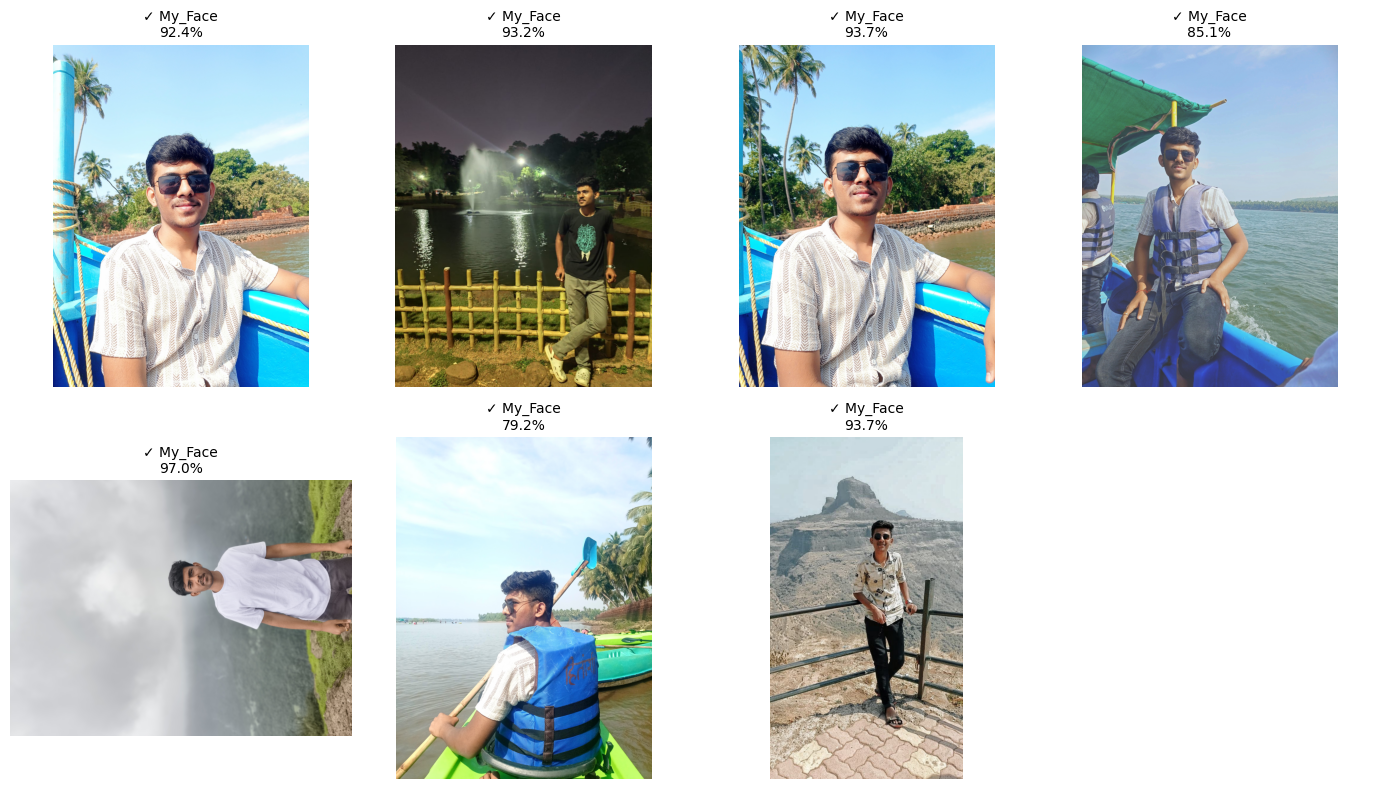

In [74]:
# visualize the test predictions
fig, axes = plt.subplots(
    2,
    4,
    figsize=(14, 8)
)

axes = axes.ravel()

for ax in axes:
    ax.axis("off")

for ax, image_path, prediction, probabilities in zip(
    axes,
    my_face_test,
    test_predictions,
    test_probabilities
):

    image = Image.open(
        image_path
    ).convert("RGB")

    predicted_name = selected_people_11[
        prediction
    ]

    confidence = np.max(probabilities) * 100

    ax.imshow(image)

    if prediction == MY_FACE_LABEL:
        title = (
            f"✓ {predicted_name}\n"
            f"{confidence:.1f}%"
        )
    else:
        title = (
            f"✗ {predicted_name}\n"
            f"{confidence:.1f}%"
        )

    ax.set_title(
        title,
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [75]:
# verify new model files
from pathlib import Path

print(
    "11-class SVM exists:",
    Path("face_recognition_svm_11class.pkl").exists()
)

print(
    "11-class classes exists:",
    Path("face_classes_11class.pkl").exists()
)

11-class SVM exists: True
11-class classes exists: True
